# Experiment 01. Color LFW Clean Baseline

## 목표

컬러 LFW 이미지를 사용하여 얼굴인식 기반 Face Authentication 파이프라인의 clean baseline을 다시 계산한다.

이후 adversarial sticker 실험을 하기 전 기준값을 확정한다.

## 수행 내용

- LFW를 `color=True`로 로드
- Enrollment / Probe split 구성
- CVLFace SOTA 얼굴인식 모델 로드
- Enrollment DB 구축
- Probe image 평가
- FAR 기준 threshold 계산
- Rank-1 accuracy, correct accept rate, misaccept rate 계산
- 공격 실험에 사용할 clean-correct accepted subset 저장

## 참고

이 노트북은 공격 패치를 만들지 않는다.  
첫 번째 실험의 목적은 컬러 이미지 기준 clean baseline과 threshold를 확정하는 것이다.

## Dependency Installation
CVLFace custom model 호환을 위해 transformers 버전 고정




In [1]:
INSTALL_DEPENDENCIES = True

if INSTALL_DEPENDENCIES:
    !pip -q uninstall -y transformers tokenizers huggingface_hub facenet-pytorch
    !pip -q install \
        "transformers==4.45.2" \
        "tokenizers>=0.20,<0.21" \
        "huggingface_hub>=0.23.2" \
        "safetensors" \
        "omegaconf" \
        "timm" \
        "fvcore" \
        "scikit-learn" \
        "matplotlib" \
        "pandas" \
        "tqdm"
    !pip -q install facenet-pytorch --no-deps

## Imports and Basic Settings

In [2]:
# ============================================================
# 1. Imports and Settings
# ============================================================

import os
import sys
import json
import math
import random
import shutil
import datetime
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF

from sklearn.datasets import fetch_lfw_people
from huggingface_hub import snapshot_download
from transformers import AutoModel
from tqdm.auto import tqdm


# ============================================================
# 2. Reproducibility
# ============================================================
# - 실험 재현성 고정
# - 동일 seed 사용

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


## Experiment Config

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ============================================================
# 3. Experiment Config
# ============================================================

# ------------------------------------------------------------
# 실행할 모델 지정
# ------------------------------------------------------------

# MODEL_NAME = "minchul/cvlface_adaface_ir101_webface12m"
# MODEL_SHORT_NAME = "adaface_ir101_wf12m"

# MODEL_NAME = "minchul/cvlface_adaface_ir101_webface4m"
# MODEL_SHORT_NAME = "adaface_ir101_wf4m"

# MODEL_NAME = "minchul/cvlface_arcface_ir101_webface4m"
# MODEL_SHORT_NAME = "arcface_ir101_wf4m"

MODEL_NAME = "minchul/cvlface_adaface_ir50_webface4m"
MODEL_SHORT_NAME = "adaface_ir50_wf4m"


# ------------------------------------------------------------
# LFW split 설정
# ------------------------------------------------------------

NUM_IDENTITIES = 100
MIN_FACES_PER_PERSON = 5
ENROLL_IMAGES_PER_ID = 1
MAX_PROBES_PER_ID = 8


# ------------------------------------------------------------
# Face authentication threshold 설정
# ------------------------------------------------------------
# - impostor similarity 상위 1% 지점을 threshold로 사용
# - FAR 1% 기준

TARGET_FAR = 0.01


# ------------------------------------------------------------
# Batch 설정
# ------------------------------------------------------------

BATCH_SIZE = 64
NUM_WORKERS = 0


# ------------------------------------------------------------
# 결과 저장 경로
# ------------------------------------------------------------
# - Google Drive에 결과 저장

DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_DRIVE_DIR = DRIVE_ROOT / "SafeAI-final-project" / "output"
RESULT_ROOT = PROJECT_DRIVE_DIR / "exp01_clean_color_lfw"

MODEL_RESULT_DIR = RESULT_ROOT / MODEL_SHORT_NAME
DETAIL_DIR = MODEL_RESULT_DIR / "details"
FIG_DIR = MODEL_RESULT_DIR / "figures"
EMB_DIR = MODEL_RESULT_DIR / "embeddings"

for d in [PROJECT_DRIVE_DIR, RESULT_ROOT, MODEL_RESULT_DIR, DETAIL_DIR, FIG_DIR, EMB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_DRIVE_DIR:", PROJECT_DRIVE_DIR)
print("MODEL_RESULT_DIR:", MODEL_RESULT_DIR)

PROJECT_DRIVE_DIR: /content/drive/MyDrive/SafeAI-final-project/output
MODEL_RESULT_DIR: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m


## Image Utilities

In [5]:
# ============================================================
# 4. Image Preprocessing
# ============================================================
# - CVLFace 계열 모델 입력: 112x112 RGB
# - pixel range: [-1, 1]

preprocess = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])


def numpy_face_to_pil(img):
    """LFW numpy image를 RGB PIL image로 변환."""

    img = np.asarray(img)

    # channel-first 형태 방어
    if img.ndim == 3 and img.shape[0] in [1, 3] and img.shape[-1] not in [1, 3]:
        img = np.transpose(img, (1, 2, 0))

    # float image 처리
    if np.issubdtype(img.dtype, np.floating):
        img = np.nan_to_num(img)

        if img.max() <= 1.5:
            img = img * 255.0

        img = np.clip(img, 0, 255).astype(np.uint8)

    else:
        img = np.clip(img, 0, 255).astype(np.uint8)

    # grayscale 방어
    if img.ndim == 2:
        return Image.fromarray(img, mode="L").convert("RGB")

    return Image.fromarray(img).convert("RGB")


def pil_to_model_tensor(pil):
    """PIL RGB image -> model input tensor."""

    return preprocess(pil.convert("RGB"))


def tensor_to_pil(x):
    """[-1, 1] normalized tensor -> PIL image."""

    x = x.detach().cpu().clamp(-1, 1)
    x = (x * 0.5 + 0.5).clamp(0, 1)

    return TF.to_pil_image(x)


def is_almost_grayscale(pil, tolerance=2):
    """RGB 이미지가 사실상 흑백인지 확인."""

    arr = np.asarray(pil.convert("RGB")).astype(np.int16)

    rg = np.abs(arr[:, :, 0] - arr[:, :, 1])
    gb = np.abs(arr[:, :, 1] - arr[:, :, 2])
    rb = np.abs(arr[:, :, 0] - arr[:, :, 2])

    gray_ratio = ((rg <= tolerance) & (gb <= tolerance) & (rb <= tolerance)).mean()

    return bool(gray_ratio > 0.98)


def show_pil_grid(images, titles=None, ncols=5, figsize=(12, 6), save_path=None):
    """PIL image list를 grid로 출력하고 저장."""

    n = len(images)

    if n == 0:
        print("No images to show.")
        return

    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)

    plt.figure(figsize=figsize)

    for i, img in enumerate(images):
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(img)
        ax.axis("off")

        if titles is not None:
            ax.set_title(titles[i], fontsize=9)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

## Load Color LFW and Build Dataset

In [6]:
# ============================================================
# 5. Dataset
# ============================================================

class FaceDataset(Dataset):
    """LFW item list를 PyTorch Dataset으로 감싼 클래스."""

    def __init__(self, items):
        self.items = list(items)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]

        return {
            "image": pil_to_model_tensor(item["pil"]),
            "identity": item["identity"],
            "index": idx,
            "role": item["role"],
            "local_index": item["local_index"],
            "lfw_index": item["lfw_index"],
        }


def load_lfw_items(
    num_identities=NUM_IDENTITIES,
    min_faces_per_person=MIN_FACES_PER_PERSON,
):
    """컬러 LFW를 로드하고 enrollment/probe split 구성."""

    # 핵심 변경점
    # - color=False가 아니라 color=True
    # - 흑백이 아닌 컬러 얼굴 이미지 사용

    lfw = fetch_lfw_people(
        min_faces_per_person=min_faces_per_person,
        resize=1.0,
        color=True,
        funneled=True,
    )

    by_id = defaultdict(list)

    for idx, img in enumerate(lfw.images):
        identity = str(lfw.target_names[lfw.target[idx]])
        pil = numpy_face_to_pil(img)

        by_id[identity].append({
            "identity": identity,
            "pil": pil,
            "lfw_index": idx,
        })

    # enrollment 1장 + probe 최소 1장 이상 가능한 identity만 사용
    eligible = [
        (identity, imgs)
        for identity, imgs in by_id.items()
        if len(imgs) >= ENROLL_IMAGES_PER_ID + 1
    ]

    eligible = sorted(eligible, key=lambda x: x[0])

    rng = np.random.default_rng(SEED)
    rng.shuffle(eligible)

    selected = eligible[:num_identities]

    enroll_items = []
    probe_items = []

    for identity, imgs in selected:
        imgs = list(imgs)
        rng.shuffle(imgs)

        enroll_imgs = imgs[:ENROLL_IMAGES_PER_ID]
        probe_imgs = imgs[ENROLL_IMAGES_PER_ID:ENROLL_IMAGES_PER_ID + MAX_PROBES_PER_ID]

        for j, face_item in enumerate(enroll_imgs):
            enroll_items.append({
                "identity": identity,
                "pil": face_item["pil"],
                "lfw_index": face_item["lfw_index"],
                "role": "enroll",
                "local_index": j,
            })

        for j, face_item in enumerate(probe_imgs):
            probe_items.append({
                "identity": identity,
                "pil": face_item["pil"],
                "lfw_index": face_item["lfw_index"],
                "role": "probe",
                "local_index": j,
            })

    return enroll_items, probe_items


enroll_items, probe_items = load_lfw_items()

enroll_ds = FaceDataset(enroll_items)
probe_ds = FaceDataset(probe_items)

print("Enrollment images:", len(enroll_ds))
print("Probe images:", len(probe_ds))
print("Identities:", len(set([x["identity"] for x in enroll_items])))

Enrollment images: 100
Probe images: 629
Identities: 100


## Save Split Metadata and Check Color Samples

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m/01_lfw_color_split_metadata.csv
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m/figures/00_color_lfw_sample_grid.png


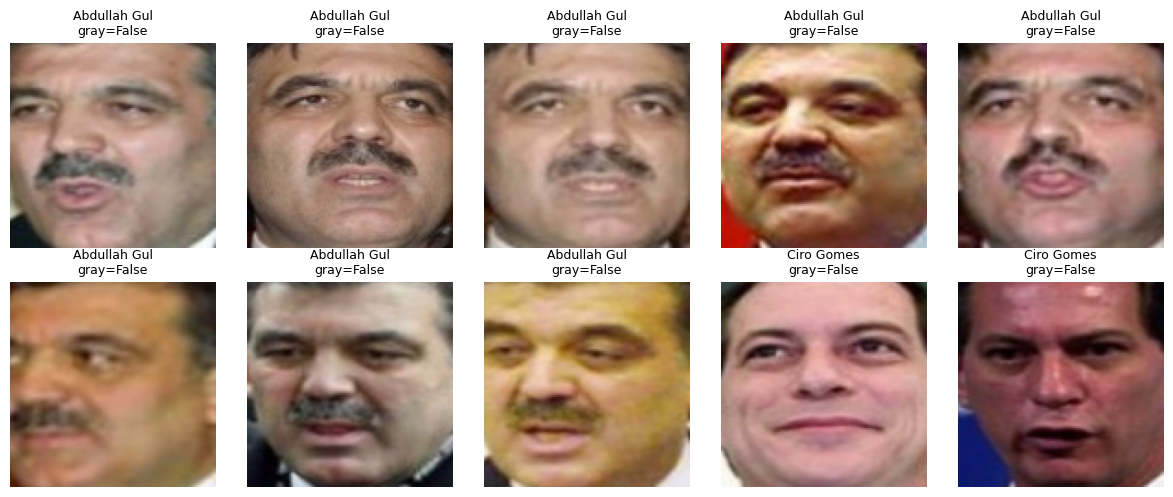

In [7]:
# ============================================================
# 6. Split Metadata and Color Check
# ============================================================
# - split 정보 저장
# - 컬러 이미지가 제대로 로드됐는지 샘플 확인
# - gray=False가 많이 나오는지 확인

split_rows = []

for i, item in enumerate(enroll_items):
    split_rows.append({
        "dataset": "enroll",
        "row": i,
        "identity": item["identity"],
        "local_index": item["local_index"],
        "lfw_index": item["lfw_index"],
    })

for i, item in enumerate(probe_items):
    split_rows.append({
        "dataset": "probe",
        "row": i,
        "identity": item["identity"],
        "local_index": item["local_index"],
        "lfw_index": item["lfw_index"],
    })

split_df = pd.DataFrame(split_rows)

split_path = MODEL_RESULT_DIR / "01_lfw_color_split_metadata.csv"
split_df.to_csv(split_path, index=False)

print("Saved:", split_path)


# 컬러 샘플 시각화
sample_items = probe_items[:10]
sample_imgs = [x["pil"].resize((112, 112)) for x in sample_items]

sample_titles = [
    f"{x['identity'][:12]}\ngray={is_almost_grayscale(x['pil'])}"
    for x in sample_items
]

show_pil_grid(
    sample_imgs,
    sample_titles,
    ncols=5,
    figsize=(12, 5),
    save_path=FIG_DIR / "00_color_lfw_sample_grid.png",
)

## CVLFace Model Loader

In [8]:
# ============================================================
# 7. CVLFace Model Loader
# ============================================================
# - 기존에 잘 돌던 loader 구조 유지
# - official files.txt loader 사용 안 함
# - direct repo loader 사용 안 함
# - sys.modules patch 사용 안 함

MODEL_CACHE = {}


def load_cvlface_model(model_name: str, device: str = DEVICE):
    """CVLFace 모델 로드."""

    if model_name in MODEL_CACHE:
        return MODEL_CACHE[model_name]

    local_path = snapshot_download(
        repo_id=model_name,
        local_dir=f"/content/{model_name.replace('/', '_')}",
        local_dir_use_symlinks=False,
    )

    if local_path not in sys.path:
        sys.path.insert(0, local_path)

    cwd = os.getcwd()
    os.chdir(local_path)

    try:
        model = AutoModel.from_pretrained(
            local_path,
            trust_remote_code=True,
            torch_dtype=torch.float32,
            local_files_only=True,
        )
    finally:
        os.chdir(cwd)

    model = model.to(device).eval()

    for p in model.parameters():
        p.requires_grad_(False)

    MODEL_CACHE[model_name] = (model, local_path)

    print("Loaded:", model_name)
    print("Local path:", local_path)

    return model, local_path


def forward_embedding(model, x):
    """모델 출력에서 face embedding 추출 후 L2 normalize."""

    out = model(x)

    if isinstance(out, dict):
        for key in ["embeddings", "embedding", "last_hidden_state", "pooler_output"]:
            if key in out:
                out = out[key]
                break

    if isinstance(out, (tuple, list)):
        out = out[0]

    if out.ndim > 2:
        out = torch.flatten(out, start_dim=1)

    return F.normalize(out.float(), p=2, dim=1)


@torch.no_grad()
def extract_embeddings(model, dataset, batch_size=BATCH_SIZE):
    """Dataset 전체 embedding 추출."""

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    embs = []
    ids = []
    indices = []

    for batch in tqdm(loader, desc="Extract embeddings"):
        x = batch["image"].to(DEVICE)
        emb = forward_embedding(model, x).cpu()

        embs.append(emb)
        ids.extend(list(batch["identity"]))

        batch_indices = batch["index"]

        if torch.is_tensor(batch_indices):
            batch_indices = batch_indices.cpu().numpy().tolist()

        indices.extend(batch_indices)

    embs = torch.cat(embs, dim=0)

    return embs, ids, indices


def build_enrollment_db(enroll_embs, enroll_ids):
    """identity별 enrollment embedding 평균으로 DB embedding 생성."""

    by_id = defaultdict(list)

    for emb, identity in zip(enroll_embs, enroll_ids):
        by_id[identity].append(emb)

    db_ids = sorted(by_id.keys())
    db_embs = []

    for identity in db_ids:
        emb = torch.stack(by_id[identity], dim=0).mean(dim=0)
        emb = F.normalize(emb, p=2, dim=0)

        db_embs.append(emb)

    db_embs = torch.stack(db_embs, dim=0)

    return db_embs, db_ids

## Metric Functions

In [9]:
# ============================================================
# 8. Metrics
# ============================================================

def compute_threshold_from_impostors(sim_mat, probe_ids, db_ids, target_far=TARGET_FAR):
    """Impostor similarity 분포에서 FAR 기준 threshold 계산."""

    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}

    impostor_sims = []

    for i, identity in enumerate(probe_ids):
        true_idx = id_to_db_idx[identity]

        mask = np.ones(len(db_ids), dtype=bool)
        mask[true_idx] = False

        impostor_sims.extend(sim_mat[i, mask].tolist())

    impostor_sims = np.array(impostor_sims, dtype=np.float32)

    threshold = float(np.quantile(impostor_sims, 1.0 - target_far))
    actual_far = float((impostor_sims >= threshold).mean())

    return threshold, actual_far, impostor_sims


def compute_facepay_metrics(embs, ids, db_embs, db_ids, threshold):
    """Identification -> Verification 구조의 metric 계산."""

    sim_mat = (embs @ db_embs.T).cpu().numpy()

    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}

    true_indices = np.array([id_to_db_idx[i] for i in ids])
    top1_indices = sim_mat.argmax(axis=1)

    top1_sims = sim_mat[np.arange(len(ids)), top1_indices]
    true_sims = sim_mat[np.arange(len(ids)), true_indices]

    top1_correct = top1_indices == true_indices
    accepted = top1_sims >= threshold

    correct_accept = top1_correct & accepted
    false_reject = ~accepted
    misidentified = ~top1_correct
    misaccept = misidentified & accepted

    metrics = {
        "n": int(len(ids)),
        "rank1_acc": float(top1_correct.mean()),
        "correct_accept_rate": float(correct_accept.mean()),
        "false_reject_rate": float(false_reject.mean()),
        "misid_rate": float(misidentified.mean()),
        "misaccept_rate": float(misaccept.mean()),
        "avg_top1_sim": float(top1_sims.mean()),
        "avg_true_sim": float(true_sims.mean()),
        "threshold": float(threshold),
    }

    detail = pd.DataFrame({
        "probe_row": np.arange(len(ids)),
        "identity": ids,
        "true_db_idx": true_indices,
        "top1_db_idx": top1_indices,
        "top1_identity": [db_ids[i] for i in top1_indices],
        "top1_similarity": top1_sims,
        "true_similarity": true_sims,
        "rank1_correct": top1_correct,
        "accepted": accepted,
        "correct_accept": correct_accept,
        "false_reject": false_reject,
        "misidentified": misidentified,
        "misaccept": misaccept,
    })

    return metrics, detail, sim_mat

## Run Clean Baseline

In [10]:
# ============================================================
# 9. Run Clean Baseline
# ============================================================
# - 모델 로드
# - enrollment DB 구성
# - probe 평가
# - threshold 계산
# - clean metric 계산

print("\n" + "=" * 80)
print("Run clean baseline")
print("=" * 80)

model, model_path = load_cvlface_model(MODEL_NAME)


# ------------------------------------------------------------
# 1. Enrollment embedding 추출
# ------------------------------------------------------------

enroll_embs_raw, enroll_ids_raw, enroll_indices = extract_embeddings(
    model,
    enroll_ds,
)


# ------------------------------------------------------------
# 2. Enrollment DB 구성
# ------------------------------------------------------------

db_embs, db_ids = build_enrollment_db(
    enroll_embs_raw,
    enroll_ids_raw,
)


# ------------------------------------------------------------
# 3. Probe embedding 추출
# ------------------------------------------------------------

probe_embs, probe_ids, probe_indices = extract_embeddings(
    model,
    probe_ds,
)


# ------------------------------------------------------------
# 4. Similarity matrix 계산
# ------------------------------------------------------------

clean_sim_mat = (probe_embs @ db_embs.T).cpu().numpy()


# ------------------------------------------------------------
# 5. FAR 기준 threshold 계산
# ------------------------------------------------------------

threshold, actual_far, impostor_sims = compute_threshold_from_impostors(
    clean_sim_mat,
    probe_ids,
    db_ids,
    target_far=TARGET_FAR,
)


# ------------------------------------------------------------
# 6. Clean metric 계산
# ------------------------------------------------------------

metrics, detail_df, _ = compute_facepay_metrics(
    probe_embs,
    probe_ids,
    db_embs,
    db_ids,
    threshold,
)


# ------------------------------------------------------------
# 7. 공격 평가용 clean-correct accepted subset 추출
# ------------------------------------------------------------

clean_eval_mask = detail_df["rank1_correct"].values & detail_df["accepted"].values
clean_eval_indices = detail_df.loc[clean_eval_mask, "probe_row"].astype(int).tolist()


metrics.update({
    "model_name": MODEL_NAME,
    "model_short_name": MODEL_SHORT_NAME,
    "model_path": model_path,
    "target_far": TARGET_FAR,
    "actual_far": actual_far,
    "n_identities": len(db_ids),
    "n_enroll": len(enroll_ds),
    "n_probe": len(probe_ds),
    "clean_eval_n": len(clean_eval_indices),
    "lfw_color": True,
    "lfw_funneled": True,
})

detail_df["model_name"] = MODEL_NAME
detail_df["model_short_name"] = MODEL_SHORT_NAME

print("Clean baseline done.")
print("Threshold:", threshold)
print("Actual FAR:", actual_far)
print("Clean eval probes:", len(clean_eval_indices))


Run clean baseline


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loaded iResNet model
compatible keys in state_dict 467 / 467
Check


<All keys matched successfully>
Loaded pretrained model from pretrained_model/model.pt
Loaded: minchul/cvlface_adaface_ir50_webface4m
Local path: /content/minchul_cvlface_adaface_ir50_webface4m


Extract embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

Extract embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

Clean baseline done.
Threshold: 0.26099666953086853
Actual FAR: 0.010004657063480592
Clean eval probes: 558


## Save CSV Outputs

In [11]:
# ============================================================
# 10. Save CSV Outputs
# ============================================================
# - summary 저장
# - per-probe detail 저장
# - clean-correct accepted subset 저장

summary_df = pd.DataFrame([metrics])

summary_cols = [
    "model_short_name",
    "model_name",
    "n_identities",
    "n_enroll",
    "n_probe",
    "target_far",
    "actual_far",
    "threshold",
    "rank1_acc",
    "correct_accept_rate",
    "false_reject_rate",
    "misid_rate",
    "misaccept_rate",
    "avg_top1_sim",
    "avg_true_sim",
    "clean_eval_n",
    "lfw_color",
    "lfw_funneled",
]

summary_df = summary_df[summary_cols]

summary_path = MODEL_RESULT_DIR / "01_clean_color_lfw_baseline_summary.csv"
detail_path = DETAIL_DIR / "01_clean_color_lfw_detail.csv"
clean_eval_path = MODEL_RESULT_DIR / "01_clean_eval_indices.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)

clean_eval_df = pd.DataFrame({
    "probe_row": clean_eval_indices,
    "identity": [probe_items[i]["identity"] for i in clean_eval_indices],
    "local_index": [probe_items[i]["local_index"] for i in clean_eval_indices],
    "lfw_index": [probe_items[i]["lfw_index"] for i in clean_eval_indices],
})

clean_eval_df.to_csv(clean_eval_path, index=False)

print("Saved summary:", summary_path)
print("Saved detail:", detail_path)
print("Saved clean eval indices:", clean_eval_path)

display(summary_df)
display(clean_eval_df.head())

Saved summary: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m/01_clean_color_lfw_baseline_summary.csv
Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m/details/01_clean_color_lfw_detail.csv
Saved clean eval indices: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m/01_clean_eval_indices.csv


,model_short_name,model_name,n_identities,n_enroll,n_probe,target_far,actual_far,threshold,rank1_acc,correct_accept_rate,false_reject_rate,misid_rate,misaccept_rate,avg_top1_sim,avg_true_sim,clean_eval_n,lfw_color,lfw_funneled
0,adaface_ir50_wf4m,minchul/cvlface_adaface_ir50_webface4m,100,100,629,0.01,0.010005,0.260997,0.903021,0.887122,0.052464,0.096979,0.060413,0.459769,0.454132,558,True,True


,probe_row,identity,local_index,lfw_index
0,0,Abdullah Gul,0,2753
1,1,Abdullah Gul,1,5277
2,2,Abdullah Gul,2,3089
3,3,Abdullah Gul,3,5651
4,4,Abdullah Gul,4,511


## Save Embeddings and Threshold

In [12]:
# ============================================================
# 11. Save Embeddings and Threshold
# ============================================================
# - 다음 공격 실험에서 재사용할 값 저장
# - DB embedding, probe embedding, identity list, threshold 저장

torch.save(db_embs, EMB_DIR / "db_embs.pt")
torch.save(probe_embs, EMB_DIR / "probe_embs.pt")

with open(EMB_DIR / "db_ids.json", "w", encoding="utf-8") as f:
    json.dump(db_ids, f, ensure_ascii=False, indent=2)

with open(EMB_DIR / "probe_ids.json", "w", encoding="utf-8") as f:
    json.dump(probe_ids, f, ensure_ascii=False, indent=2)

with open(EMB_DIR / "threshold.json", "w", encoding="utf-8") as f:
    json.dump({
        "target_far": TARGET_FAR,
        "actual_far": actual_far,
        "threshold": threshold,
    }, f, ensure_ascii=False, indent=2)

print("Saved embeddings and threshold:", EMB_DIR)

Saved embeddings and threshold: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m/embeddings


## Visualization

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m/figures/01_clean_rank1_accuracy.png


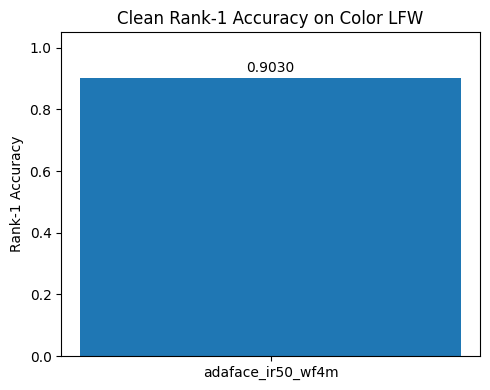

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m/figures/01_clean_correct_accept_rate.png


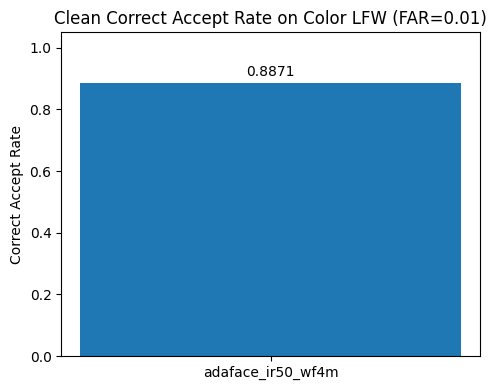

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m/figures/01_clean_misaccept_rate.png


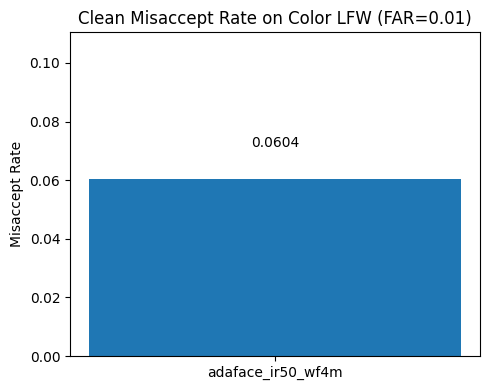

In [13]:
# ============================================================
# 12. Visualization
# ============================================================
# - 발표용 단일 모델 bar plot 저장
# - top-4 모델 비교 그래프는 모델별 summary CSV를 합친 뒤 별도 생성 권장

def save_single_bar(metric_name, value, title, ylabel, filename, ylim=None):
    """단일 metric bar plot 저장."""

    plt.figure(figsize=(5, 4))

    plt.bar([MODEL_SHORT_NAME], [value])
    plt.ylabel(ylabel)
    plt.title(title)

    plt.text(
        0,
        value + 0.01,
        f"{value:.4f}" if isinstance(value, float) else str(value),
        ha="center",
        va="bottom",
        fontsize=10,
    )

    if ylim is not None:
        plt.ylim(*ylim)

    plt.tight_layout()

    out_path = FIG_DIR / filename
    plt.savefig(out_path, dpi=200, bbox_inches="tight")

    print("Saved:", out_path)
    plt.show()


save_single_bar(
    "rank1_acc",
    metrics["rank1_acc"],
    "Clean Rank-1 Accuracy on Color LFW",
    "Rank-1 Accuracy",
    "01_clean_rank1_accuracy.png",
    ylim=(0, 1.05),
)

save_single_bar(
    "correct_accept_rate",
    metrics["correct_accept_rate"],
    f"Clean Correct Accept Rate on Color LFW (FAR={TARGET_FAR})",
    "Correct Accept Rate",
    "01_clean_correct_accept_rate.png",
    ylim=(0, 1.05),
)

save_single_bar(
    "misaccept_rate",
    metrics["misaccept_rate"],
    f"Clean Misaccept Rate on Color LFW (FAR={TARGET_FAR})",
    "Misaccept Rate",
    "01_clean_misaccept_rate.png",
    ylim=(0, max(0.05, metrics["misaccept_rate"] + 0.05)),
)

## Interpretation Memo

이 실험은 color=True LFW 기준 clean baseline이다.

발표에서 사용할 포인트는 다음과 같다.

1. 흑백이 아니라 컬러 얼굴 이미지로 실험 환경을 다시 구성했다.
2. Enrollment image로 identity DB를 만들고, probe image를 identification → verification 구조로 평가했다.
3. Threshold는 impostor similarity 분포에서 FAR 기준으로 설정했다.
4. 이후 adversarial sticker 실험은 clean 상태에서 올바르게 accept된 probe subset을 기준으로 진행한다.
5. 따라서 공격 성공률은 clean 상태에서도 실패하던 샘플을 포함하지 않고, 실제 인증이 잘 되던 샘플이 공격으로 얼마나 무너지는지를 보여준다.

다음 실험에서는 `01_clean_eval_indices.csv`에 포함된 probe subset을 사용하여 일반 스티커와 adversarial sticker를 비교한다.

Detect landmarks for enroll_items:   0%|          | 0/100 [00:00<?, ?it/s]

enroll_items: mtcnn=99, fallback=1


Detect landmarks for probe_items:   0%|          | 0/629 [00:00<?, ?it/s]

probe_items: mtcnn=627, fallback=2
Rebuilt datasets with landmarks.
enroll_ds: 100
probe_ds: 629
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir50_wf4m/figures/exp02_landmark_detection_sample.png


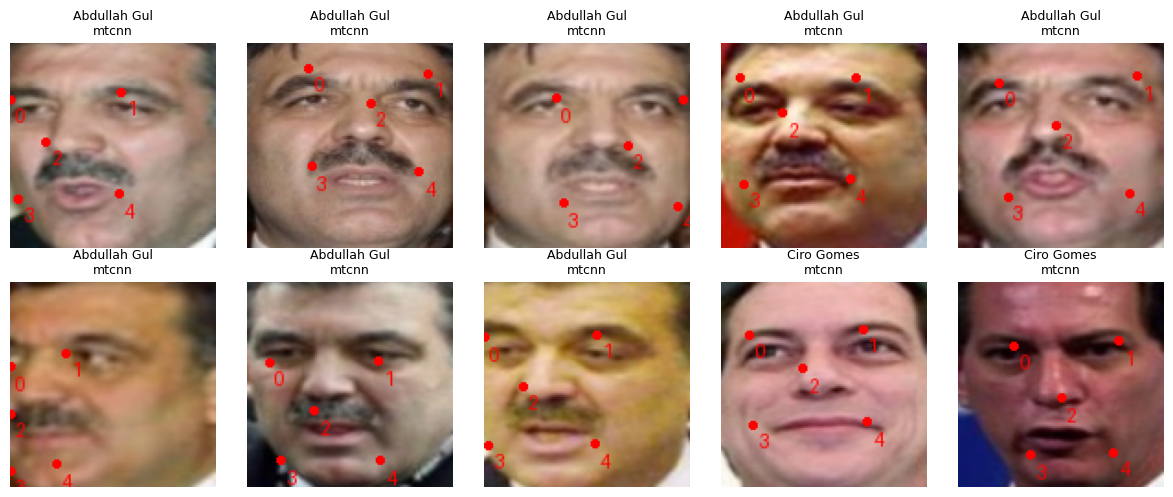

In [14]:
# ============================================================
# Exp02-0. Landmark Detection for Realistic Sticker Placement
# ============================================================
# 목적
# - fixed coordinate가 아니라 눈/코/입 landmark 기준으로 스티커 위치를 잡는다.
# - LFW 이미지별 얼굴 위치/비율 차이를 반영한다.
# - 기존 facepay_sticker_pipeline 코드의 MTCNN 5-point landmark 방식을 사용한다.

# facenet_pytorch가 없으면 먼저 설치
try:
    from facenet_pytorch import MTCNN
except ImportError:
    !pip -q install facenet-pytorch
    from facenet_pytorch import MTCNN

from PIL import ImageDraw

USE_LANDMARK_BASED_PLACEMENT = True
LANDMARK_FALLBACK_TO_CANONICAL = True

# 112x112 aligned face에서의 fallback landmark
# order = left_eye, right_eye, nose, left_mouth, right_mouth
CANONICAL_LANDMARKS_112 = np.array([
    [38.0, 42.0],   # left_eye
    [74.0, 42.0],   # right_eye
    [56.0, 60.0],   # nose
    [42.0, 78.0],   # left_mouth
    [70.0, 78.0],   # right_mouth
], dtype=np.float32)

LANDMARK_MTCNN = MTCNN(
    image_size=112,
    margin=0,
    keep_all=True,
    post_process=False,
    device=DEVICE,
)


def detect_landmarks_112(pil, detector=LANDMARK_MTCNN):
    """
    PIL face image -> 112x112 model input coordinate의 5-point landmark 반환.

    Return:
      landmarks: np.ndarray [5, 2]
      source: "mtcnn" or "canonical_fallback"
      prob: detector confidence or np.nan
    """

    img112 = pil.convert("RGB").resize((112, 112), Image.BILINEAR)

    try:
        boxes, probs, landmarks = detector.detect(img112, landmarks=True)
    except Exception:
        boxes, probs, landmarks = None, None, None

    if landmarks is not None and len(landmarks) > 0:
        if probs is None:
            best_idx = 0
            best_prob = np.nan
        else:
            probs_arr = np.asarray(probs, dtype=np.float32)
            valid = np.nan_to_num(probs_arr, nan=-1.0)
            best_idx = int(valid.argmax())
            best_prob = float(probs_arr[best_idx])

        lm = np.asarray(landmarks[best_idx], dtype=np.float32)

        if lm.shape == (5, 2) and np.isfinite(lm).all():
            lm[:, 0] = np.clip(lm[:, 0], 0, 111)
            lm[:, 1] = np.clip(lm[:, 1], 0, 111)
            return lm, "mtcnn", best_prob

    if LANDMARK_FALLBACK_TO_CANONICAL:
        return CANONICAL_LANDMARKS_112.copy(), "canonical_fallback", np.nan

    raise RuntimeError("MTCNN landmark detection failed and fallback is disabled.")


def add_landmarks_to_items(items, desc="items"):
    """
    enroll_items / probe_items에 landmarks를 추가한다.
    이미 있으면 건너뛴다.
    """

    mtcnn_count = 0
    fallback_count = 0

    for item in tqdm(items, desc=f"Detect landmarks for {desc}"):
        if "landmarks" in item:
            source = item.get("landmark_source", "unknown")
        else:
            landmarks, source, prob = detect_landmarks_112(item["pil"])
            item["landmarks"] = landmarks
            item["landmark_source"] = source
            item["landmark_prob"] = prob

        if source == "mtcnn":
            mtcnn_count += 1
        else:
            fallback_count += 1

    print(f"{desc}: mtcnn={mtcnn_count}, fallback={fallback_count}")


def draw_landmarks_on_pil(pil, landmarks, radius=2):
    """
    landmark detection 확인용 시각화.
    """

    img = pil.convert("RGB").resize((112, 112), Image.BILINEAR)
    draw = ImageDraw.Draw(img)

    for i, (x, y) in enumerate(np.asarray(landmarks)):
        draw.ellipse(
            [x - radius, y - radius, x + radius, y + radius],
            fill=(255, 0, 0),
        )
        draw.text((x + 3, y + 3), str(i), fill=(255, 0, 0))

    return img


# exp01에서 만들어진 item에 landmark 추가
add_landmarks_to_items(enroll_items, desc="enroll_items")
add_landmarks_to_items(probe_items, desc="probe_items")


# FaceDataset을 landmark 반환 버전으로 재정의
class FaceDataset(Dataset):
    def __init__(self, items):
        self.items = list(items)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        landmarks = item.get("landmarks", CANONICAL_LANDMARKS_112)

        return {
            "image": pil_to_model_tensor(item["pil"]),
            "identity": item["identity"],
            "index": idx,
            "role": item.get("role", "unknown"),
            "local_index": item.get("local_index", -1),
            "lfw_index": item.get("lfw_index", -1),
            "landmarks": torch.tensor(landmarks, dtype=torch.float32),
            "landmark_source": item.get("landmark_source", "unknown"),
        }


# 같은 split으로 dataset만 다시 생성
enroll_ds = FaceDataset(enroll_items)
probe_ds = FaceDataset(probe_items)

print("Rebuilt datasets with landmarks.")
print("enroll_ds:", len(enroll_ds))
print("probe_ds:", len(probe_ds))


# landmark 시각화 샘플 저장
landmark_sample_imgs = []
landmark_sample_titles = []

for item in probe_items[:10]:
    landmark_sample_imgs.append(
        draw_landmarks_on_pil(item["pil"], item["landmarks"])
    )
    landmark_sample_titles.append(
        f"{item['identity'][:12]}\n{item.get('landmark_source', 'unknown')}"
    )

show_pil_grid(
    landmark_sample_imgs,
    landmark_sample_titles,
    ncols=5,
    figsize=(12, 5),
    save_path=FIG_DIR / "exp02_landmark_detection_sample.png",
)

In [15]:
# ============================================================
# Exp02. Normal Sticker vs Adversarial Sticker
# ============================================================
# 목적
# - clean-correct accepted probe subset만 대상으로 평가
# - no sticker / normal mascot sticker / adversarial mascot sticker 비교
# - 일반 스티커 때문인지, 최적화된 adversarial pattern 때문인지 분리해서 분석

from pathlib import Path
import io
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm


# ------------------------------------------------------------
# Exp02 저장 경로
# ------------------------------------------------------------

EXP02_ROOT = PROJECT_DRIVE_DIR / "exp02_normal_vs_adversarial_sticker_color_lfw"
EXP02_DIR = EXP02_ROOT / MODEL_SHORT_NAME
EXP02_DETAIL_DIR = EXP02_DIR / "details"
EXP02_FIG_DIR = EXP02_DIR / "figures"
EXP02_PATCH_DIR = EXP02_DIR / "patches"

for d in [EXP02_ROOT, EXP02_DIR, EXP02_DETAIL_DIR, EXP02_FIG_DIR, EXP02_PATCH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("EXP02_DIR:", EXP02_DIR)


# ------------------------------------------------------------
# Sticker / attack 설정
# ------------------------------------------------------------


MASCOT_PATH = DRIVE_ROOT / "SafeAI-final-project/mask/puang.png"
DEFAULT_LOCATION = "nose_bridge"
DEFAULT_PATCH_SIZE_RATIO = 0.30

ATTACK_STEPS = 1000
ATTACK_BATCH_SIZE = 32
ATTACK_LR = 0.05

# soft threshold-aware loss 설정
TAU = 0.05
MARGIN = 0.05
THRESHOLD_MARGIN = 0.00

LAMBDA_TRUE = 1.0
LAMBDA_IMP = 2.0
LAMBDA_THRESH = 2.0
LAMBDA_RANK = 1.0
TV_WEIGHT = 0.0

# 발표용 상세 저장 여부
SAVE_DETAILS = True

print("MODEL:", MODEL_SHORT_NAME)
print("Location:", DEFAULT_LOCATION)
print("Patch size ratio:", DEFAULT_PATCH_SIZE_RATIO)
print("Attack steps:", ATTACK_STEPS)

EXP02_DIR: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m
MODEL: adaface_ir50_wf4m
Location: nose_bridge
Patch size ratio: 0.3
Attack steps: 1000


In [16]:
# ============================================================
# 1. Evaluation Dataset
# ============================================================
# - exp01에서 clean 상태로 올바르게 인증된 probe만 공격 평가에 사용
# - 공격으로 인해 "정상 인증되던 샘플"이 어떻게 변하는지 보기 위함

class IndexedSubsetDataset(Dataset):
    def __init__(self, base_ds, indices):
        self.base_ds = base_ds
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = self.indices[idx]
        item = self.base_ds[base_idx]
        item["base_probe_row"] = base_idx
        return item


eval_ds = IndexedSubsetDataset(probe_ds, clean_eval_indices)

print("Eval subset size:", len(eval_ds))


# ============================================================
# 2. Landmark-relative Patch placement utilities
# ============================================================
# fixed coordinate는 fallback으로만 사용한다.
# 기본 실험은 MTCNN 5-point landmark 기준 상대 위치를 사용한다.

LOCATION_CENTERS = {
    "forehead": (56, 30),
    "nose_bridge": (56, 45),
    "center": (56, 56),
    "nose": (56, 60),

    "left_cheek": (42, 66),
    "right_cheek": (70, 66),

    "left_under_eye": (43, 52),
    "right_under_eye": (69, 52),
    "under_eye": (56, 52),

    "mouth": (56, 76),
    "chin": (56, 88),
}


def get_patch_size_px(patch_size_ratio, image_size=112):
    return max(4, min(image_size, int(round(image_size * float(patch_size_ratio)))))


def center_to_top_left(center_xy, patch_size_px, image_size=112):
    cx, cy = center_xy

    x0 = int(round(cx - patch_size_px / 2))
    y0 = int(round(cy - patch_size_px / 2))

    x0 = max(0, min(image_size - patch_size_px, x0))
    y0 = max(0, min(image_size - patch_size_px, y0))

    return x0, y0


def get_landmark_based_centers(landmarks, location, image_size=112):
    """
    MTCNN 5-point landmark로 샘플별 sticker center를 계산한다.

    landmarks: [B, 5, 2] or [5, 2]
    order = left_eye, right_eye, nose, left_mouth, right_mouth

    Return:
      centers: [B, 2]
    """

    if location not in LOCATION_CENTERS:
        raise ValueError(f"Unknown location: {location}")

    lm = landmarks

    if not torch.is_tensor(lm):
        lm = torch.tensor(lm, dtype=torch.float32)

    lm = lm.float()

    if lm.ndim == 2:
        lm = lm.unsqueeze(0)

    if lm.ndim != 3 or lm.shape[1:] != (5, 2):
        raise ValueError(f"landmarks must be [B,5,2] or [5,2], got {tuple(lm.shape)}")

    left_eye = lm[:, 0, :]
    right_eye = lm[:, 1, :]
    nose = lm[:, 2, :]
    left_mouth = lm[:, 3, :]
    right_mouth = lm[:, 4, :]

    eye_mid = (left_eye + right_eye) / 2.0
    mouth_mid = (left_mouth + right_mouth) / 2.0

    eye_dist = torch.linalg.norm(
        right_eye - left_eye,
        dim=1,
        keepdim=True,
    ).clamp(min=8.0)

    if location == "nose_bridge":
        # 눈 중간점과 코 사이
        center = 0.55 * eye_mid + 0.45 * nose

    elif location in ["center", "nose"]:
        center = nose

    elif location == "forehead":
        # eye_mid에서 nose 반대 방향, 즉 위쪽으로 이동
        center = eye_mid + 0.75 * (eye_mid - nose)

    elif location == "left_under_eye":
        center = 0.65 * left_eye + 0.35 * nose

    elif location == "right_under_eye":
        center = 0.65 * right_eye + 0.35 * nose

    elif location == "under_eye":
        left_center = 0.65 * left_eye + 0.35 * nose
        right_center = 0.65 * right_eye + 0.35 * nose
        center = (left_center + right_center) / 2.0

    elif location == "left_cheek":
        center = 0.35 * left_eye + 0.65 * left_mouth
        center = center + torch.cat(
            [-0.22 * eye_dist, -0.03 * eye_dist],
            dim=1,
        )

    elif location == "right_cheek":
        center = 0.35 * right_eye + 0.65 * right_mouth
        center = center + torch.cat(
            [0.22 * eye_dist, -0.03 * eye_dist],
            dim=1,
        )

    elif location == "mouth":
        center = mouth_mid

    elif location == "chin":
        center = mouth_mid + 0.80 * (mouth_mid - nose)

    else:
        fixed = torch.tensor(
            LOCATION_CENTERS[location],
            dtype=lm.dtype,
            device=lm.device,
        )
        center = fixed[None, :].expand(lm.shape[0], -1)

    center[:, 0] = center[:, 0].clamp(0, image_size - 1)
    center[:, 1] = center[:, 1].clamp(0, image_size - 1)

    return center


def centers_to_top_lefts(centers, patch_size_px, image_size=112):
    """
    centers [B,2] -> integer top-left tensor [B,2].
    """

    x0 = torch.round(centers[:, 0] - patch_size_px / 2.0).long()
    y0 = torch.round(centers[:, 1] - patch_size_px / 2.0).long()

    x0 = x0.clamp(0, image_size - patch_size_px)
    y0 = y0.clamp(0, image_size - patch_size_px)

    return torch.stack([x0, y0], dim=1)


def get_patch_top_lefts(
    location,
    patch_size_px,
    batch_size,
    image_size=112,
    landmarks=None,
    device=DEVICE,
):
    """
    landmarks가 있으면 landmark-relative placement 사용.
    없으면 fixed coordinate fallback 사용.
    """

    if USE_LANDMARK_BASED_PLACEMENT and landmarks is not None:
        centers = get_landmark_based_centers(
            landmarks,
            location,
            image_size=image_size,
        ).to(device)

        return centers_to_top_lefts(
            centers,
            patch_size_px,
            image_size=image_size,
        )

    x0, y0 = center_to_top_left(
        LOCATION_CENTERS[location],
        patch_size_px,
        image_size=image_size,
    )

    return torch.tensor(
        [[x0, y0]],
        dtype=torch.long,
        device=device,
    ).expand(batch_size, -1)


def load_mascot_patch_and_mask(patch_size_px, mascot_path=MASCOT_PATH, device=DEVICE):
    """
    마스코트 PNG를 patch tensor와 shape mask로 변환한다.
    - patch: [1, 3, P, P], range [-1, 1]
    - mask : [1, 1, P, P], range [0, 1]
    """

    if not Path(mascot_path).exists():
        raise FileNotFoundError(
            f"마스코트 파일이 없습니다: {mascot_path}\n"
            "MASCOT_PATH를 Google Drive 경로로 수정했는지 확인하세요."
        )

    img = Image.open(mascot_path).convert("RGBA")
    img = img.resize((patch_size_px, patch_size_px), Image.BILINEAR)

    arr = np.asarray(img).astype(np.float32) / 255.0

    rgb = arr[:, :, :3]
    alpha = arr[:, :, 3:4]

    patch = torch.tensor(rgb).permute(2, 0, 1).unsqueeze(0)
    patch = patch * 2.0 - 1.0

    mask = torch.tensor(alpha).permute(2, 0, 1).unsqueeze(0)
    mask = mask[:, :1].clamp(0, 1)

    return patch.to(device).float(), mask.to(device).float()


def apply_patch_tensor(
    x,
    patch,
    mask,
    location=DEFAULT_LOCATION,
    landmarks=None,
):
    """
    x에 patch를 붙인다.

    x: [B, 3, 112, 112], range [-1, 1]
    patch: [1, 3, P, P]
    mask: [1, 1, P, P]

    landmarks가 있으면 각 샘플의 눈/코/입 기준 상대 위치에 붙인다.
    landmarks가 없으면 fixed coordinate fallback을 사용한다.
    """

    if location not in LOCATION_CENTERS:
        raise ValueError(f"Unknown location: {location}")

    B, C, H, W = x.shape
    image_size = min(H, W)
    P = patch.shape[-1]

    top_lefts = get_patch_top_lefts(
        location=location,
        patch_size_px=P,
        batch_size=B,
        image_size=image_size,
        landmarks=landmarks,
        device=x.device,
    )

    x_adv = x.clone()

    patch_b = patch.to(x.device, dtype=x.dtype)
    mask_b = mask.to(x.device, dtype=x.dtype)

    for i in range(B):
        x0 = int(top_lefts[i, 0].item())
        y0 = int(top_lefts[i, 1].item())

        region = x_adv[i:i + 1, :, y0:y0 + P, x0:x0 + P]

        patched_region = (
            region * (1.0 - mask_b)
            + patch_b * mask_b
        )

        x_adv[i:i + 1, :, y0:y0 + P, x0:x0 + P] = patched_region

    return x_adv


def save_patch_png(patch, mask, path):
    """
    patch tensor를 PNG로 저장한다.
    """

    patch = patch.detach().cpu().clamp(-1, 1)
    mask = mask.detach().cpu().clamp(0, 1)

    rgb = (patch[0] * 0.5 + 0.5).clamp(0, 1)
    alpha = mask[0].clamp(0, 1)

    rgba = torch.cat([rgb, alpha], dim=0)
    pil = TF.to_pil_image(rgba)

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    pil.save(path)

    print("Saved:", path)

Eval subset size: 558


In [17]:
# ============================================================
# 3. Evaluation with optional sticker
# ============================================================

@torch.no_grad()
def extract_embeddings_with_optional_patch(
    model,
    dataset,
    patch=None,
    mask=None,
    location=DEFAULT_LOCATION,
    batch_size=BATCH_SIZE,
):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    embs = []
    ids = []
    base_probe_rows = []

    for batch in tqdm(loader, desc="Eval"):
        x = batch["image"].to(DEVICE)

        if patch is not None and mask is not None:
            landmarks = batch.get("landmarks", None)

            if landmarks is not None:
                landmarks = landmarks.to(DEVICE)

            x = apply_patch_tensor(
                x,
                patch=patch,
                mask=mask,
                location=location,
                landmarks=landmarks,
            )

        emb = forward_embedding(model, x).cpu()

        embs.append(emb)
        ids.extend(list(batch["identity"]))

        rows = batch["base_probe_row"]
        if torch.is_tensor(rows):
            rows = rows.cpu().numpy().tolist()

        base_probe_rows.extend(rows)

    embs = torch.cat(embs, dim=0)

    return embs, ids, base_probe_rows


def evaluate_condition(
    condition_name,
    dataset,
    patch=None,
    mask=None,
    location=DEFAULT_LOCATION,
    save_detail=SAVE_DETAILS,
):
    """
    특정 condition의 face authentication metric 계산.
    """

    embs, ids, base_probe_rows = extract_embeddings_with_optional_patch(
        model=model,
        dataset=dataset,
        patch=patch,
        mask=mask,
        location=location,
    )

    metrics, detail, _ = compute_facepay_metrics(
        embs=embs,
        ids=ids,
        db_embs=db_embs,
        db_ids=db_ids,
        threshold=threshold,
    )

    # clean true similarity와 비교하기 위한 similarity drop 계산
    clean_true_map = detail_df.set_index("probe_row")["true_similarity"].to_dict()
    before_true = np.array([clean_true_map[i] for i in base_probe_rows])
    after_true = detail["true_similarity"].values

    metrics.update({
        "model_short_name": MODEL_SHORT_NAME,
        "model_name": MODEL_NAME,
        "condition": condition_name,
        "location": location,
        "patch_size_ratio": DEFAULT_PATCH_SIZE_RATIO,
        "threshold": float(threshold),
        "avg_similarity_drop": float((before_true - after_true).mean()),
        "placement": "landmark_relative" if USE_LANDMARK_BASED_PLACEMENT else "fixed_coordinate",
    })

    detail["model_short_name"] = MODEL_SHORT_NAME
    detail["condition"] = condition_name
    detail["base_probe_row"] = base_probe_rows
    detail["similarity_drop_from_clean"] = before_true - after_true

    if save_detail:
        safe_name = condition_name.replace(" ", "_").replace("/", "_")
        detail_path = EXP02_DETAIL_DIR / f"02_{safe_name}_detail.csv"
        detail.to_csv(detail_path, index=False)
        print("Saved detail:", detail_path)

    return metrics, detail


# ------------------------------------------------------------
# No sticker baseline on eval subset
# ------------------------------------------------------------

no_sticker_metrics, no_sticker_detail = evaluate_condition(
    condition_name="no_sticker_eval_subset",
    dataset=eval_ds,
    patch=None,
    mask=None,
    location=DEFAULT_LOCATION,
)

display(pd.DataFrame([no_sticker_metrics]))

Eval:   0%|          | 0/9 [00:00<?, ?it/s]

Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/details/02_no_sticker_eval_subset_detail.csv


,n,rank1_acc,correct_accept_rate,false_reject_rate,misid_rate,misaccept_rate,avg_top1_sim,avg_true_sim,threshold,model_short_name,model_name,condition,location,patch_size_ratio,avg_similarity_drop,placement
0,558,1.0,1.0,0.0,0.0,0.0,0.482503,0.482503,0.260997,adaface_ir50_wf4m,minchul/cvlface_adaface_ir50_webface4m,no_sticker_eval_subset,nose_bridge,0.3,-3.952279e-08,landmark_relative


In [18]:
# ============================================================
# 4. Normal mascot sticker baseline
# ============================================================
# - 같은 위치, 같은 크기의 일반 스티커를 붙였을 때 오인식률 확인
# - adversarial sticker 성능이 단순 occlusion 때문인지 구분하기 위한 baseline

P = get_patch_size_px(DEFAULT_PATCH_SIZE_RATIO)

normal_patch, normal_mask = load_mascot_patch_and_mask(
    patch_size_px=P,
    mascot_path=MASCOT_PATH,
    device=DEVICE,
)

save_patch_png(
    normal_patch,
    normal_mask,
    EXP02_PATCH_DIR / "02_normal_mascot_sticker.png",
)

normal_metrics, normal_detail = evaluate_condition(
    condition_name="normal_mascot_sticker",
    dataset=eval_ds,
    patch=normal_patch,
    mask=normal_mask,
    location=DEFAULT_LOCATION,
)

display(pd.DataFrame([normal_metrics]))

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/patches/02_normal_mascot_sticker.png


Eval:   0%|          | 0/9 [00:00<?, ?it/s]

Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/details/02_normal_mascot_sticker_detail.csv


,n,rank1_acc,correct_accept_rate,false_reject_rate,misid_rate,misaccept_rate,avg_top1_sim,avg_true_sim,threshold,model_short_name,model_name,condition,location,patch_size_ratio,avg_similarity_drop,placement
0,558,0.973118,0.96595,0.014337,0.026882,0.019713,0.461568,0.46082,0.260997,adaface_ir50_wf4m,minchul/cvlface_adaface_ir50_webface4m,normal_mascot_sticker,nose_bridge,0.3,0.021683,landmark_relative


In [19]:
# ============================================================
# 5. Adversarial sticker optimization
# ============================================================
# 목적
# - true identity similarity는 낮춘다
# - impostor similarity는 높인다
# - threshold를 넘기도록 유도한다
# - true identity보다 impostor가 더 높은 rank를 갖도록 유도한다

def total_variation_loss(patch, mask=None):
    if mask is not None:
        patch = patch * mask

    dx = torch.mean(torch.abs(patch[:, :, :, 1:] - patch[:, :, :, :-1]))
    dy = torch.mean(torch.abs(patch[:, :, 1:, :] - patch[:, :, :-1, :]))

    return dx + dy


def optimize_adversarial_sticker(
    model,
    dataset,
    db_embs,
    db_ids,
    init_patch,
    shape_mask,
    location=DEFAULT_LOCATION,
    steps=ATTACK_STEPS,
    batch_size=ATTACK_BATCH_SIZE,
    lr=ATTACK_LR,
):
    """
    Soft threshold-aware adversarial sticker optimization.
    """

    db_t = db_embs.to(DEVICE)
    threshold_t = torch.tensor(float(threshold), device=DEVICE)

    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}

    patch = init_patch.clone().detach().to(DEVICE)
    mask = shape_mask.clone().detach().to(DEVICE)

    patch.requires_grad_(True)

    optimizer = torch.optim.Adam([patch], lr=lr)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )

    history = []
    step_iter = 0

    pbar = tqdm(total=steps, desc="Optimize adversarial sticker")

    while step_iter < steps:
        for batch in loader:
            if step_iter >= steps:
                break

            x = batch["image"].to(DEVICE)
            ids = list(batch["identity"])

            true_idx = torch.tensor(
                [id_to_db_idx[i] for i in ids],
                dtype=torch.long,
                device=DEVICE,
            )

            landmarks = batch.get("landmarks", None)

            if landmarks is not None:
                landmarks = landmarks.to(DEVICE)

            patched_x = apply_patch_tensor(
                x,
                patch=patch.clamp(-1, 1),
                mask=mask,
                location=location,
                landmarks=landmarks,
            )

            emb = forward_embedding(model, patched_x)
            sim = emb @ db_t.T

            batch_arange = torch.arange(sim.shape[0], device=DEVICE)

            true_sim = sim[batch_arange, true_idx]

            sim_other = sim.clone()
            sim_other[batch_arange, true_idx] = -1e9

            max_impostor_sim, max_impostor_idx = sim_other.max(dim=1)
            soft_impostor_sim = TAU * torch.logsumexp(sim_other / TAU, dim=1)

            # 1) true identity similarity 낮추기
            loss_true = true_sim.mean()

            # 2) soft impostor similarity 높이기
            loss_imp = -soft_impostor_sim.mean()

            # 3) impostor similarity가 threshold를 넘도록 유도
            loss_thresh = torch.relu(
                threshold_t + THRESHOLD_MARGIN - soft_impostor_sim
            ).mean()

            # 4) impostor가 true identity보다 높아지도록 유도
            loss_rank = torch.relu(
                true_sim - soft_impostor_sim + MARGIN
            ).mean()

            tv = total_variation_loss(patch, mask)

            attack_loss = (
                LAMBDA_TRUE * loss_true
                + LAMBDA_IMP * loss_imp
                + LAMBDA_THRESH * loss_thresh
                + LAMBDA_RANK * loss_rank
            )

            loss = attack_loss + TV_WEIGHT * tv

            optimizer.zero_grad()
            loss.backward()

            grad_norm = (
                patch.grad.detach().abs().mean().item()
                if patch.grad is not None
                else 0.0
            )

            optimizer.step()

            with torch.no_grad():
                patch.clamp_(-1, 1)

            if step_iter % 10 == 0 or step_iter == steps - 1:
                with torch.no_grad():
                    frac_imp_over_threshold = (
                        max_impostor_sim > threshold_t
                    ).float().mean()

                    frac_misrank = (
                        max_impostor_sim > true_sim
                    ).float().mean()

                    row = {
                        "step": step_iter,
                        "loss": float(loss.detach().cpu()),
                        "attack_loss": float(attack_loss.detach().cpu()),
                        "loss_true": float(loss_true.detach().cpu()),
                        "loss_imp": float(loss_imp.detach().cpu()),
                        "loss_thresh": float(loss_thresh.detach().cpu()),
                        "loss_rank": float(loss_rank.detach().cpu()),
                        "tv": float(tv.detach().cpu()),
                        "true_sim": float(true_sim.mean().detach().cpu()),
                        "soft_impostor_sim": float(soft_impostor_sim.mean().detach().cpu()),
                        "max_impostor_sim": float(max_impostor_sim.mean().detach().cpu()),
                        "gap_true_minus_impostor": float((true_sim - max_impostor_sim).mean().detach().cpu()),
                        "frac_imp_over_threshold": float(frac_imp_over_threshold.detach().cpu()),
                        "frac_misrank": float(frac_misrank.detach().cpu()),
                        "grad_norm": float(grad_norm),
                    }

                    history.append(row)

                    pbar.set_postfix({
                        "loss": row["loss"],
                        "true": row["true_sim"],
                        "max_imp": row["max_impostor_sim"],
                        "misrank": row["frac_misrank"],
                    })

            step_iter += 1
            pbar.update(1)

    pbar.close()

    adv_patch = patch.detach().clamp(-1, 1)
    history_df = pd.DataFrame(history)

    return adv_patch, mask, history_df


adv_patch, adv_mask, attack_history = optimize_adversarial_sticker(
    model=model,
    dataset=eval_ds,
    db_embs=db_embs,
    db_ids=db_ids,
    init_patch=normal_patch,
    shape_mask=normal_mask,
    location=DEFAULT_LOCATION,
    steps=ATTACK_STEPS,
    batch_size=ATTACK_BATCH_SIZE,
    lr=ATTACK_LR,
)


# ------------------------------------------------------------
# Save adversarial patch and optimization history
# ------------------------------------------------------------

adv_patch_path = EXP02_PATCH_DIR / "02_adversarial_mascot_sticker.png"
adv_patch_pt_path = EXP02_PATCH_DIR / "02_adversarial_mascot_sticker.pt"
history_path = EXP02_DIR / "02_attack_optimization_history.csv"

save_patch_png(adv_patch, adv_mask, adv_patch_path)

torch.save({
    "patch": adv_patch.detach().cpu(),
    "mask": adv_mask.detach().cpu(),
    "model_name": MODEL_NAME,
    "model_short_name": MODEL_SHORT_NAME,
    "location": DEFAULT_LOCATION,
    "patch_size_ratio": DEFAULT_PATCH_SIZE_RATIO,
    "threshold": float(threshold),
    "attack_steps": ATTACK_STEPS,
    "attack_lr": ATTACK_LR,
    "loss_type": "soft_threshold_aware",
}, adv_patch_pt_path)

attack_history.to_csv(history_path, index=False)

print("Saved adv patch:", adv_patch_path)
print("Saved adv patch pt:", adv_patch_pt_path)
print("Saved history:", history_path)

display(attack_history.tail())

Optimize adversarial sticker:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/patches/02_adversarial_mascot_sticker.png
Saved adv patch: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/patches/02_adversarial_mascot_sticker.png
Saved adv patch pt: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/patches/02_adversarial_mascot_sticker.pt
Saved history: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/02_attack_optimization_history.csv


,step,loss,attack_loss,loss_true,loss_imp,loss_thresh,loss_rank,tv,true_sim,soft_impostor_sim,max_impostor_sim,gap_true_minus_impostor,frac_imp_over_threshold,frac_misrank,grad_norm
96,960,-0.335914,-0.335914,0.337813,-0.361478,0.0,0.049228,0.643600,0.337813,0.361478,0.269244,0.068569,0.50000,0.28125,0.000122
97,970,-0.381691,-0.381691,0.295046,-0.357761,0.0,0.038784,0.644768,0.295046,0.357761,0.269808,0.025238,0.53125,0.50000,0.000094
98,980,-0.391095,-0.391095,0.298326,-0.362475,0.0,0.035529,0.644498,0.298326,0.362475,0.274748,0.023578,0.62500,0.46875,0.000086
99,990,-0.365816,-0.365816,0.305079,-0.361169,0.0,0.051444,0.645487,0.305079,0.361169,0.266296,0.038784,0.56250,0.46875,0.000089
100,999,-0.361024,-0.361024,0.331180,-0.371426,0.0,0.050648,0.644055,0.331180,0.371426,0.282876,0.048305,0.68750,0.37500,0.000104


Eval:   0%|          | 0/9 [00:00<?, ?it/s]

Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/details/02_adversarial_mascot_sticker_detail.csv
Saved summary: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/02_normal_vs_adversarial_summary.csv


,model_short_name,condition,placement,n,location,patch_size_ratio,threshold,rank1_acc,correct_accept_rate,false_reject_rate,misid_rate,misaccept_rate,avg_top1_sim,avg_true_sim,avg_similarity_drop
0,adaface_ir50_wf4m,no_sticker_eval_subset,landmark_relative,558,nose_bridge,0.3,0.260997,1.000000,1.000000,0.000000,0.000000,0.000000,0.482503,0.482503,-3.952279e-08
1,adaface_ir50_wf4m,normal_mascot_sticker,landmark_relative,558,nose_bridge,0.3,0.260997,0.973118,0.965950,0.014337,0.026882,0.019713,0.461568,0.460820,2.168296e-02
2,adaface_ir50_wf4m,adversarial_mascot_sticker,landmark_relative,558,nose_bridge,0.3,0.260997,0.637993,0.625448,0.105735,0.362007,0.268817,0.344175,0.317192,1.653113e-01


Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/figures/02_misaccept_rate_normal_vs_adv.png


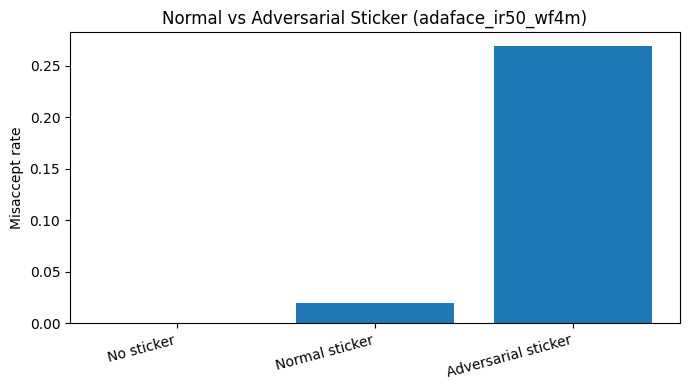

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/figures/02_similarity_drop_normal_vs_adv.png


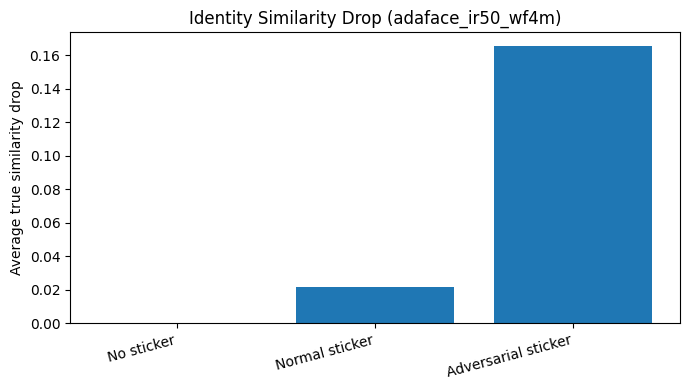

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/figures/02_attack_optimization_trajectory.png


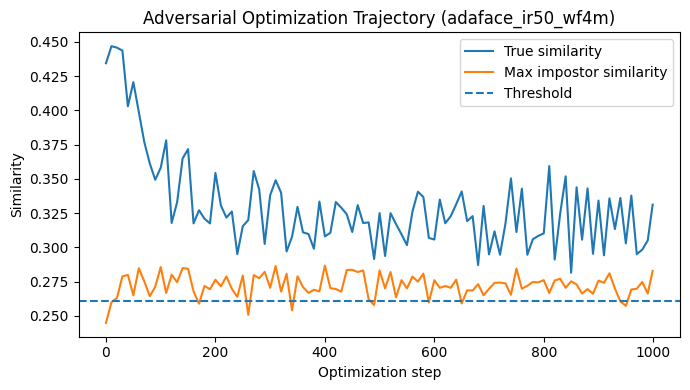

In [20]:
# ============================================================
# 6. Evaluate adversarial sticker
# ============================================================

adv_metrics, adv_detail = evaluate_condition(
    condition_name="adversarial_mascot_sticker",
    dataset=eval_ds,
    patch=adv_patch,
    mask=adv_mask,
    location=DEFAULT_LOCATION,
)

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

exp02_summary_df = pd.DataFrame([
    no_sticker_metrics,
    normal_metrics,
    adv_metrics,
])

summary_cols = [
    "model_short_name",
    "condition",
    "placement",
    "n",
    "location",
    "patch_size_ratio",
    "threshold",
    "rank1_acc",
    "correct_accept_rate",
    "false_reject_rate",
    "misid_rate",
    "misaccept_rate",
    "avg_top1_sim",
    "avg_true_sim",
    "avg_similarity_drop",
]

exp02_summary_df = exp02_summary_df[summary_cols]

summary_path = EXP02_DIR / "02_normal_vs_adversarial_summary.csv"
exp02_summary_df.to_csv(summary_path, index=False)

print("Saved summary:", summary_path)
display(exp02_summary_df)


# ------------------------------------------------------------
# 발표용 핵심 그래프 1: misaccept rate
# ------------------------------------------------------------

plot_df = exp02_summary_df.copy()

label_map = {
    "no_sticker_eval_subset": "No sticker",
    "normal_mascot_sticker": "Normal sticker",
    "adversarial_mascot_sticker": "Adversarial sticker",
}

plot_df["label"] = plot_df["condition"].map(label_map).fillna(plot_df["condition"])

plt.figure(figsize=(7, 4))
plt.bar(plot_df["label"], plot_df["misaccept_rate"])
plt.ylabel("Misaccept rate")
plt.title(f"Normal vs Adversarial Sticker ({MODEL_SHORT_NAME})")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

fig_path = EXP02_FIG_DIR / "02_misaccept_rate_normal_vs_adv.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


# ------------------------------------------------------------
# 발표용 핵심 그래프 2: true similarity drop
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.bar(plot_df["label"], plot_df["avg_similarity_drop"])
plt.ylabel("Average true similarity drop")
plt.title(f"Identity Similarity Drop ({MODEL_SHORT_NAME})")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

fig_path = EXP02_FIG_DIR / "02_similarity_drop_normal_vs_adv.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


# ------------------------------------------------------------
# optimization trajectory
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(attack_history["step"], attack_history["true_sim"], label="True similarity")
plt.plot(attack_history["step"], attack_history["max_impostor_sim"], label="Max impostor similarity")
plt.axhline(float(threshold), linestyle="--", label="Threshold")
plt.xlabel("Optimization step")
plt.ylabel("Similarity")
plt.title(f"Adversarial Optimization Trajectory ({MODEL_SHORT_NAME})")
plt.legend()
plt.tight_layout()

fig_path = EXP02_FIG_DIR / "02_attack_optimization_trajectory.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved qualitative grid: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/figures/02_qualitative_clean_normal_adv_grid.png
Saved qualitative metadata: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m/02_qualitative_examples_metadata.csv


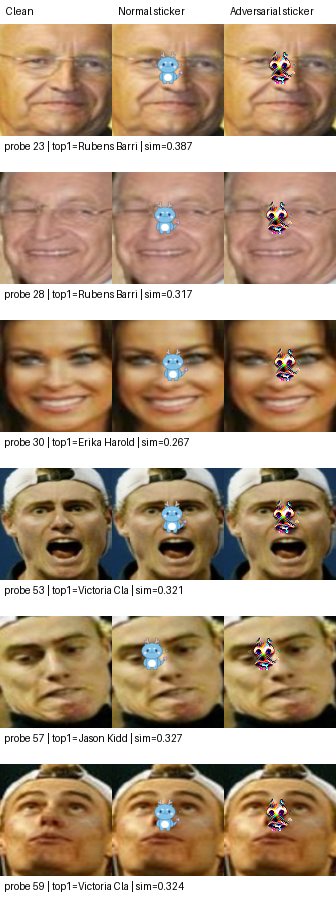

,base_probe_row,true_identity,adv_top1_identity,adv_top1_similarity,adv_true_similarity,adv_misaccept
0,23,Edmund Stoiber,Rubens Barrichello,0.387204,0.281697,True
1,28,Edmund Stoiber,Rubens Barrichello,0.316866,0.300471,True
2,30,Carmen Electra,Erika Harold,0.267399,0.151978,True
3,53,Lleyton Hewitt,Victoria Clarke,0.320558,0.258062,True
4,57,Lleyton Hewitt,Jason Kidd,0.326501,0.166888,True
5,59,Lleyton Hewitt,Victoria Clarke,0.323881,0.322261,True


In [21]:
# ============================================================
# 7. Qualitative examples
# ============================================================
# - clean / normal sticker / adversarial sticker를 한 grid로 저장
# - 발표 슬라이드에 바로 사용

def add_patch_to_pil_for_visual(
    pil,
    patch,
    mask,
    location=DEFAULT_LOCATION,
    landmarks=None,
):
    x = pil_to_model_tensor(pil).unsqueeze(0).to(DEVICE)

    lm = None

    if landmarks is not None:
        lm = torch.tensor(
            landmarks,
            dtype=torch.float32,
            device=DEVICE,
        ).unsqueeze(0)

    y = apply_patch_tensor(
        x,
        patch=patch.to(DEVICE),
        mask=mask.to(DEVICE),
        location=location,
        landmarks=lm,
    )

    return tensor_to_pil(y[0])


def make_qualitative_grid(
    adv_detail,
    normal_patch,
    normal_mask,
    adv_patch,
    adv_mask,
    num_examples=6,
):
    # adversarial misaccept 성공 사례 우선 사용
    candidates = adv_detail[adv_detail["misaccept"] == True].copy()

    if len(candidates) == 0:
        print("[WARN] No misaccept samples. Use misidentified samples instead.")
        candidates = adv_detail[adv_detail["misidentified"] == True].copy()

    if len(candidates) == 0:
        print("[WARN] No misidentified samples. Use first samples instead.")
        candidates = adv_detail.head(num_examples).copy()

    selected = candidates.head(num_examples)

    cell_w = 112
    cell_h = 148
    ncols = 3
    nrows = len(selected)

    canvas = Image.new(
        "RGB",
        (cell_w * ncols, cell_h * nrows + 24),
        "white",
    )

    draw = ImageDraw.Draw(canvas)

    headers = ["Clean", "Normal sticker", "Adversarial sticker"]

    for c, h in enumerate(headers):
        draw.text((c * cell_w + 6, 5), h, fill=(0, 0, 0))

    metadata_rows = []

    for r, row in enumerate(selected.itertuples()):
        base_idx = int(row.base_probe_row)

        clean_pil = probe_items[base_idx]["pil"].resize((112, 112))
        landmarks = probe_items[base_idx].get(
            "landmarks",
            CANONICAL_LANDMARKS_112,
        )

        normal_pil = add_patch_to_pil_for_visual(
            probe_items[base_idx]["pil"],
            normal_patch,
            normal_mask,
            DEFAULT_LOCATION,
            landmarks=landmarks,
        )

        adv_pil = add_patch_to_pil_for_visual(
            probe_items[base_idx]["pil"],
            adv_patch,
            adv_mask,
            DEFAULT_LOCATION,
            landmarks=landmarks,
        )

        y = 24 + r * cell_h

        canvas.paste(clean_pil, (0, y))
        canvas.paste(normal_pil, (cell_w, y))
        canvas.paste(adv_pil, (cell_w * 2, y))

        caption = (
            f"probe {base_idx} | "
            f"top1={str(row.top1_identity)[:12]} | "
            f"sim={row.top1_similarity:.3f}"
        )

        draw.text((4, y + 116), caption, fill=(0, 0, 0))

        metadata_rows.append({
            "base_probe_row": base_idx,
            "true_identity": row.identity,
            "adv_top1_identity": row.top1_identity,
            "adv_top1_similarity": row.top1_similarity,
            "adv_true_similarity": row.true_similarity,
            "adv_misaccept": row.misaccept,
        })

    return canvas, pd.DataFrame(metadata_rows)


qual_grid, qual_meta = make_qualitative_grid(
    adv_detail=adv_detail,
    normal_patch=normal_patch,
    normal_mask=normal_mask,
    adv_patch=adv_patch,
    adv_mask=adv_mask,
    num_examples=6,
)

qual_path = EXP02_FIG_DIR / "02_qualitative_clean_normal_adv_grid.png"
qual_meta_path = EXP02_DIR / "02_qualitative_examples_metadata.csv"

qual_grid.save(qual_path)
qual_meta.to_csv(qual_meta_path, index=False)

print("Saved qualitative grid:", qual_path)
print("Saved qualitative metadata:", qual_meta_path)

display(qual_grid)
display(qual_meta)

In [22]:
# ============================================================
# 8. Exp02 output summary
# ============================================================

print("Exp02 done.")
print("Result directory:", EXP02_DIR)

print("\nSaved files:")
for p in sorted(EXP02_DIR.rglob("*")):
    if p.is_file():
        print("-", p.relative_to(EXP02_DIR))

Exp02 done.
Result directory: /content/drive/MyDrive/SafeAI-final-project/output/exp02_normal_vs_adversarial_sticker_color_lfw/adaface_ir50_wf4m

Saved files:
- 02_attack_optimization_history.csv
- 02_normal_vs_adversarial_summary.csv
- 02_qualitative_examples_metadata.csv
- details/02_adversarial_mascot_sticker_detail.csv
- details/02_no_sticker_eval_subset_detail.csv
- details/02_normal_mascot_sticker_detail.csv
- figures/02_attack_optimization_trajectory.png
- figures/02_misaccept_rate_normal_vs_adv.png
- figures/02_qualitative_clean_normal_adv_grid.png
- figures/02_similarity_drop_normal_vs_adv.png
- patches/02_adversarial_mascot_sticker.png
- patches/02_adversarial_mascot_sticker.pt
- patches/02_normal_mascot_sticker.png
